# Toxic Comment Detection - Model Training

This notebook implements and evaluates two NLP models for toxic comment
detection on social media platforms:

1. Baseline Model: TF-IDF + Logistic Regression
2. Advanced Model: DistilBERT (fine-tuned)

This notebook is a continuation of the preprocessing pipeline completed
by the data preprocessing team. It loads the processed Jigsaw dataset
and trains, evaluates, and compares both models.

Author: Amit Kour
Dataset: Jigsaw Toxic Comment Classification Challenge
Repository: https://github.com/JohnCoffey-commits/toxic_comment_detection

## 1. Environment Setup

Mount Google Drive to access the project repository and dataset files
stored persistently across Colab sessions.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Install Dependencies

Install and verify all required Python libraries for preprocessing,
model training, and evaluation.

In [7]:
%pip install -q pandas numpy scikit-learn pyarrow PyYAML transformers torch

import pandas as pd
import numpy as np
import sklearn
import pyarrow
import yaml
import transformers

print('pandas:', pd.__version__)
print('numpy:', np.__version__)
print('scikit-learn:', sklearn.__version__)
print('pyarrow:', pyarrow.__version__)
print('PyYAML:', yaml.__version__)
print('transformers:', transformers.__version__)

pandas: 2.2.2
numpy: 2.0.2
scikit-learn: 1.6.1
pyarrow: 18.1.0
PyYAML: 6.0.3
transformers: 5.0.0


## 3. Load Project Repository

Load the project repository from Google Drive. The repository contains
John's preprocessing pipeline and processed dataset files required for
model training.

In [8]:
import os

DRIVE_PROJECT = '/content/drive/MyDrive/Colab Notebooks/toxic_comment_detection'

if not os.path.exists(DRIVE_PROJECT):
    %cd /content/drive/MyDrive/Colab\ Notebooks/
    !git clone https://github.com/JohnCoffey-commits/toxic_comment_detection.git
    print("Repo cloned successfully!")
else:
    print("Repo already exists in Drive, skipping clone!")

print("\nFolder contents:")
for item in os.listdir(DRIVE_PROJECT):
    print(f"  {item}")

Repo already exists in Drive, skipping clone!

Folder contents:
  .git
  .gitignore
  colab_file
  data
  docs
  metadata
  reports
  requirements.txt
  src
  dataset
  baseline_confusion_matrix.png


## 4. Verify Raw Dataset

Verify that the raw Jigsaw dataset is available at the expected path
before running the preprocessing pipeline.

In [9]:
import os

dataset_path = '/content/drive/MyDrive/Colab Notebooks/toxic_comment_detection/dataset/jigsaw/raw'
train_path = dataset_path + '/train.csv'

print("Dataset folder exists:", os.path.exists(dataset_path))
print("train.csv exists:", os.path.exists(train_path))

if os.path.exists(train_path):
    size = os.path.getsize(train_path) / (1024 * 1024)
    print(f"train.csv size: {size:.1f} MB")
else:
    print("train.csv is MISSING - please upload it to:", dataset_path)

Dataset folder exists: True
train.csv exists: True
train.csv size: 65.6 MB


## 5. Run Preprocessing Pipeline

Run John's existing preprocessing pipeline to generate the processed
dataset files required for model training. The pipeline performs text
cleaning, binary label creation, and train/val/test splitting.

In [10]:
import os
import sys

PROJECT_ROOT = '/content/drive/MyDrive/Colab Notebooks/toxic_comment_detection'

os.chdir(PROJECT_ROOT)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Working directory:", os.getcwd())
print("Project root on sys.path:", PROJECT_ROOT in sys.path)

Working directory: /content/drive/MyDrive/Colab Notebooks/toxic_comment_detection
Project root on sys.path: True


### 5.1 Import Preprocessing Pipeline

Import the existing preprocessing package from the project repository.

In [11]:
from src.preprocessing.config import PipelineConfig
from src.preprocessing.pipeline import run_pipeline, setup_logging

print("Preprocessing pipeline imported successfully.")

Preprocessing pipeline imported successfully.


### 5.2 Configure and Execute Pipeline

Configure the preprocessing pipeline with the correct input and output
paths, then execute it to generate the processed dataset files including
the training, validation and test splits.

In [12]:
from pathlib import Path
from src.preprocessing.pipeline import run_pipeline, setup_logging
from src.preprocessing.config import PipelineConfig

PROJECT_ROOT = Path('/content/drive/MyDrive/Colab Notebooks/toxic_comment_detection')

setup_logging()

config = PipelineConfig(
    project_root=PROJECT_ROOT,
    jigsaw_raw_path=PROJECT_ROOT / 'dataset' / 'jigsaw' / 'raw' / 'train.csv',
    civil_raw_path=PROJECT_ROOT / 'dataset' / 'civil_comments' / 'raw' / 'train.csv',
    processed_dir=PROJECT_ROOT / 'data' / 'processed',
    metadata_dir=PROJECT_ROOT / 'metadata',
    report_dir=PROJECT_ROOT / 'reports' / 'preprocessing',
    require_transformers_tokenizer=True,
)

print("Configuration created successfully.")
print("Jigsaw raw path:", config.jigsaw_raw_path)
print("Jigsaw file exists:", config.jigsaw_raw_path.exists())
print("Processed dir:", config.processed_dir)

Configuration created successfully.
Jigsaw raw path: /content/drive/MyDrive/Colab Notebooks/toxic_comment_detection/dataset/jigsaw/raw/train.csv
Jigsaw file exists: True
Processed dir: /content/drive/MyDrive/Colab Notebooks/toxic_comment_detection/data/processed


### 5.3 Execute Pipeline

Execute the preprocessing pipeline to generate cleaned and split
dataset files. This step produces the train, validation and test
splits used for model training and evaluation.

In [13]:
report_payload = run_pipeline(config)

print("Preprocessing complete.")
print("Warnings:", report_payload.get('warnings', []))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (631 > 512). Running this sequence through the model will result in indexing errors


Preprocessing complete.
Warnings: ['Civil Comments file missing; optional extension artifacts skipped.']


### 5.4 Verify Processed Output Files

Verify that the preprocessing pipeline has successfully generated all
required dataset splits for model training and evaluation.

In [14]:
import os

processed_dir = '/content/drive/MyDrive/Colab Notebooks/toxic_comment_detection/data/processed'

print("Generated files in data/processed:")
for file in sorted(os.listdir(processed_dir)):
    size = os.path.getsize(os.path.join(processed_dir, file)) / (1024 * 1024)
    print(f"  {file}  ({size:.1f} MB)")

Generated files in data/processed:
  jigsaw_identity_slice.csv  (26.6 MB)
  jigsaw_identity_slice.parquet  (16.6 MB)
  jigsaw_implicit_proxy_slice.csv  (11.0 MB)
  jigsaw_implicit_proxy_slice.parquet  (6.1 MB)
  jigsaw_obfuscation_slice.csv  (126.3 MB)
  jigsaw_obfuscation_slice.parquet  (77.0 MB)
  jigsaw_test.csv  (33.4 MB)
  jigsaw_test.parquet  (20.3 MB)
  jigsaw_train.csv  (155.7 MB)
  jigsaw_train.parquet  (94.4 MB)
  jigsaw_val.csv  (33.5 MB)
  jigsaw_val.parquet  (20.4 MB)
  test.csv  (17.7 MB)
  train.csv  (82.5 MB)
  val.csv  (17.8 MB)


### 5.5 Preview Processed Training Data

Load and inspect the processed training dataset to verify the column
structure and label distribution before model training.

In [15]:
import pandas as pd

processed_dir = '/content/drive/MyDrive/Colab Notebooks/toxic_comment_detection/data/processed'

train = pd.read_parquet(f'{processed_dir}/jigsaw_train.parquet')

print("Shape:", train.shape)
print("\nColumns:", train.columns.tolist())
print("\nFirst 3 rows:")
print(train.head(3))
print("\nLabel distribution:")
print(train['binary_label'].value_counts())
print(train['binary_label'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Shape: (111519, 17)

Columns: ['sample_id', 'source_dataset', 'raw_text', 'text_clean', 'text_tfidf', 'binary_label', 'orig_label_info', 'char_len', 'word_len', 'text_hash_raw', 'text_hash_normalized', 'bert_token_len', 'has_identity_term', 'has_obfuscation', 'implicit_proxy', 'length_bucket', 'split']

First 3 rows:
         sample_id source_dataset  \
0  jigsaw_00000000         jigsaw   
1  jigsaw_00000001         jigsaw   
2  jigsaw_00000002         jigsaw   

                                            raw_text  \
0  Explanation\nWhy the edits made under my usern...   
1  D'aww! He matches this background colour I'm s...   
2  Hey man, I'm really not trying to edit war. It...   

                                          text_clean  \
0  Explanation Why the edits made under my userna...   
1  D'aww! He matches this background colour I'm s...   
2  Hey man, I'm really not trying to edit war. It...   

                                          text_tfidf  binary_label  \
0  explanati

## 6. Model Training and Evaluation

This section implements and evaluates two models for toxic comment
detection:

1. Baseline Model: TF-IDF + Logistic Regression
2. Advanced Model: DistilBERT (fine-tuned)

Both models are evaluated using accuracy, precision, recall, F1 score
and confusion matrix. Results are compared at the end to demonstrate
the advantage of the advanced model.

In [16]:
import pandas as pd
from pathlib import Path

processed_dir = Path('/content/drive/MyDrive/Colab Notebooks/toxic_comment_detection/data/processed')

# Load all three splits
train = pd.read_parquet(processed_dir / 'jigsaw_train.parquet')
val   = pd.read_parquet(processed_dir / 'jigsaw_val.parquet')
test  = pd.read_parquet(processed_dir / 'jigsaw_test.parquet')

# Extract relevant columns
X_train = train['text_tfidf']
X_val   = val['text_tfidf']
X_test  = test['text_tfidf']

y_train = train['binary_label']
y_val   = val['binary_label']
y_test  = test['binary_label']

print("Train size:", len(train))
print("Val size:  ", len(val))
print("Test size: ", len(test))
print("\nClass distribution in train:")
print(y_train.value_counts())

Train size: 111519
Val size:   23897
Test size:  23897

Class distribution in train:
binary_label
0    100196
1     11323
Name: count, dtype: int64


## 7. Baseline Model: TF-IDF + Logistic Regression

The baseline model uses TF-IDF (Term Frequency-Inverse Document
Frequency) vectorisation combined with Logistic Regression for
binary toxic comment classification.

TF-IDF converts raw text into numerical feature vectors by weighing
the importance of each word relative to the entire corpus. Logistic
Regression then learns decision boundaries on these features to
classify comments as toxic or non-toxic.

Class imbalance is handled by setting class_weight='balanced' in
Logistic Regression, which automatically adjusts weights inversely
proportional to class frequencies.

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
import numpy as np

print("Training Baseline Model: TF-IDF + Logistic Regression")
print("="*55)

# Step 1: TF-IDF Vectorisation
print("\nStep 1: Fitting TF-IDF Vectoriser...")
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Vocabulary size: {len(tfidf.vocabulary_):,}")
print(f"Training matrix shape: {X_train_tfidf.shape}")

# Step 2: Train Logistic Regression
print("\nStep 2: Training Logistic Regression...")
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    C=1.0,
    solver='lbfgs'
)

lr_model.fit(X_train_tfidf, y_train)
print("Training complete.")

# Step 3: Evaluate on Validation Set
print("\nStep 3: Evaluating on Validation Set...")
val_preds = lr_model.predict(X_val_tfidf)

print("\nValidation Results:")
print(f"  Accuracy:  {accuracy_score(y_val, val_preds):.4f}")
print(f"  Precision: {precision_score(y_val, val_preds):.4f}")
print(f"  Recall:    {recall_score(y_val, val_preds):.4f}")
print(f"  F1 Score:  {f1_score(y_val, val_preds):.4f}")

Training Baseline Model: TF-IDF + Logistic Regression

Step 1: Fitting TF-IDF Vectoriser...
Vocabulary size: 50,000
Training matrix shape: (111519, 50000)

Step 2: Training Logistic Regression...
Training complete.

Step 3: Evaluating on Validation Set...

Validation Results:
  Accuracy:  0.9405
  Precision: 0.6612
  Recall:    0.8495
  F1 Score:  0.7436


### 7.1 Baseline Model Test Set Evaluation

Evaluate the trained TF-IDF + Logistic Regression model on the
held-out test set and visualise the confusion matrix to analyse
prediction errors.

Baseline Model - Test Set Evaluation

Test Results:
  Accuracy:  0.9411
  Precision: 0.6613
  Recall:    0.8603
  F1 Score:  0.7478

Detailed Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.98      0.95      0.97     21471
       Toxic       0.66      0.86      0.75      2426

    accuracy                           0.94     23897
   macro avg       0.82      0.91      0.86     23897
weighted avg       0.95      0.94      0.94     23897



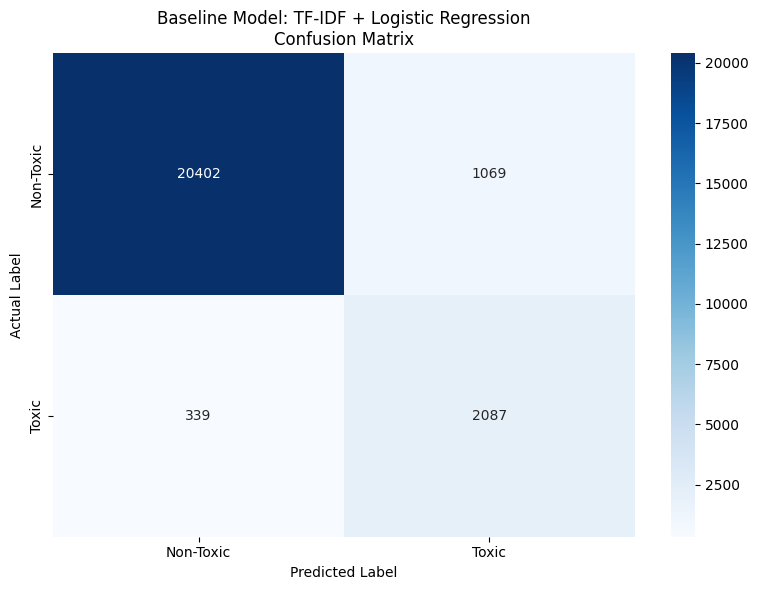

Confusion matrix saved.


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 4: Evaluate on Test Set
print("Baseline Model - Test Set Evaluation")
print("="*55)

test_preds = lr_model.predict(X_test_tfidf)

accuracy  = accuracy_score(y_test, test_preds)
precision = precision_score(y_test, test_preds)
recall    = recall_score(y_test, test_preds)
f1        = f1_score(y_test, test_preds)

print(f"\nTest Results:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, test_preds,
      target_names=['Non-Toxic', 'Toxic']))

# Confusion Matrix
cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Toxic', 'Toxic'],
            yticklabels=['Non-Toxic', 'Toxic'])
plt.title('Baseline Model: TF-IDF + Logistic Regression\nConfusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved.")

## 8. Advanced Model: DistilBERT

DistilBERT is a lightweight transformer model that retains 97% of
BERT's language understanding capability while being 40% smaller
and 60% faster. Unlike TF-IDF which treats words as independent
features, DistilBERT captures contextual relationships between
words through its self-attention mechanism, making it significantly
more effective for nuanced toxic comment detection.

The model is fine-tuned on the Jigsaw training set for binary
classification using the text_clean column as input.

In [19]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.optim import AdamW
from transformers import get_scheduler
import numpy as np

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# Load tokeniser
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
print("Tokeniser loaded successfully.")

# Use a subset for faster training on free Colab
TRAIN_SIZE = 20000
VAL_SIZE   = 3000
TEST_SIZE  = 3000

train_texts  = train['text_clean'].iloc[:TRAIN_SIZE].tolist()
train_labels = train['binary_label'].iloc[:TRAIN_SIZE].tolist()

val_texts    = val['text_clean'].iloc[:VAL_SIZE].tolist()
val_labels   = val['binary_label'].iloc[:VAL_SIZE].tolist()

test_texts   = test['text_clean'].iloc[:TEST_SIZE].tolist()
test_labels  = test['binary_label'].iloc[:TEST_SIZE].tolist()

print(f"\nUsing subsets for efficient training:")
print(f"  Train: {len(train_texts):,} samples")
print(f"  Val:   {len(val_texts):,} samples")
print(f"  Test:  {len(test_texts):,} samples")

Device: cuda
Tokeniser loaded successfully.

Using subsets for efficient training:
  Train: 20,000 samples
  Val:   3,000 samples
  Test:  3,000 samples


### 8.2 Tokenisation and Dataset Preparation

Tokenise all text samples using the DistilBERT tokeniser with a
maximum sequence length of 256 tokens and prepare PyTorch DataLoader
objects for efficient batch processing during training.

In [20]:
class ToxicCommentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }

print("Tokenising datasets...")

train_dataset = ToxicCommentDataset(train_texts, train_labels, tokenizer)
val_dataset   = ToxicCommentDataset(val_texts,   val_labels,   tokenizer)
test_dataset  = ToxicCommentDataset(test_texts,  test_labels,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:  ", len(val_loader))
print("Test batches: ", len(test_loader))
print("\nDatasets and dataloaders created successfully.")

Tokenising datasets...
Train batches: 625
Val batches:   94
Test batches:  94

Datasets and dataloaders created successfully.


### 8.3 Model Initialisation and Training Setup

Load the pre-trained DistilBERT model for sequence classification
and configure the optimiser and learning rate scheduler for
fine-tuning over 3 epochs.

In [21]:
from transformers import DistilBertForSequenceClassification
from torch.optim import AdamW
from transformers import get_scheduler

# Load pre-trained DistilBERT for binary classification
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)
model.to(device)
print("Model loaded and moved to:", device)

# Optimiser
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

# Learning rate scheduler
NUM_EPOCHS = 3
num_training_steps = NUM_EPOCHS * len(train_loader)
num_warmup_steps   = num_training_steps // 10

scheduler = get_scheduler(
    'linear',
    optimizer=optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

print(f"Training steps:  {num_training_steps}")
print(f"Warmup steps:    {num_warmup_steps}")
print(f"Epochs:          {NUM_EPOCHS}")
print("\nModel and training setup complete.")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded and moved to: cuda
Training steps:  1875
Warmup steps:    187
Epochs:          3

Model and training setup complete.


### 8.4 Model Fine-Tuning

Fine-tune the DistilBERT model on the Jigsaw training set over 3
epochs. Training loss and validation F1 score are tracked after
each epoch to monitor model performance and detect overfitting.

In [22]:
from sklearn.metrics import f1_score, accuracy_score
import time

# Define training parameters
NUM_EPOCHS = 3

def evaluate(model, dataloader, device):
    model.eval()
    all_preds  = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    f1       = f1_score(all_labels, all_preds)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, f1, accuracy

# Training loop
print("Starting DistilBERT Fine-Tuning...")
print("="*55)

train_losses  = []
val_f1_scores = []

for epoch in range(NUM_EPOCHS):
    model.train()
    total_train_loss = 0
    start_time = time.time()

    for batch_idx, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        total_train_loss += loss.item()

        if (batch_idx + 1) % 100 == 0:
            print(f"  Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_train_loss = total_train_loss / len(train_loader)
    val_loss, val_f1, val_acc = evaluate(model, val_loader, device)
    epoch_time = time.time() - start_time

    train_losses.append(avg_train_loss)
    val_f1_scores.append(val_f1)

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS} Summary:")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")
    print(f"  Val F1:     {val_f1:.4f}")
    print(f"  Val Acc:    {val_acc:.4f}")
    print(f"  Time:       {epoch_time/60:.1f} mins")
    print("-"*55)

print("\nFine-tuning complete!")

Starting DistilBERT Fine-Tuning...
  Epoch 1 | Batch 100/625 | Loss: 0.1616
  Epoch 1 | Batch 200/625 | Loss: 0.2337
  Epoch 1 | Batch 300/625 | Loss: 0.0805
  Epoch 1 | Batch 400/625 | Loss: 0.0370
  Epoch 1 | Batch 500/625 | Loss: 0.1332
  Epoch 1 | Batch 600/625 | Loss: 0.0629

Epoch 1/3 Summary:
  Train Loss: 0.1680
  Val Loss:   0.1122
  Val F1:     0.8061
  Val Acc:    0.9577
  Time:       7.6 mins
-------------------------------------------------------
  Epoch 2 | Batch 100/625 | Loss: 0.0033
  Epoch 2 | Batch 200/625 | Loss: 0.0734
  Epoch 2 | Batch 300/625 | Loss: 0.1231
  Epoch 2 | Batch 400/625 | Loss: 0.1112
  Epoch 2 | Batch 500/625 | Loss: 0.0044
  Epoch 2 | Batch 600/625 | Loss: 0.0417

Epoch 2/3 Summary:
  Train Loss: 0.0716
  Val Loss:   0.1315
  Val F1:     0.7917
  Val Acc:    0.9533
  Time:       7.7 mins
-------------------------------------------------------
  Epoch 3 | Batch 100/625 | Loss: 0.1643
  Epoch 3 | Batch 200/625 | Loss: 0.0023
  Epoch 3 | Batch 300/625

### 8.5 Save Fine-Tuned Model

Save the fine-tuned DistilBERT model to Google Drive immediately
after training to prevent loss of trained weights if the Colab
session restarts.

In [24]:
import os

save_path = '/content/drive/MyDrive/Colab Notebooks/toxic_comment_detection/model'
os.makedirs(save_path, exist_ok=True)

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print("Model saved successfully.")
print("Location:", save_path)
print("Contents:", os.listdir(save_path))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully.
Location: /content/drive/MyDrive/Colab Notebooks/toxic_comment_detection/model
Contents: ['config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json']


### 8.6 DistilBERT Test Set Evaluation

Evaluate the fine-tuned DistilBERT model on the held-out test set
and visualise the confusion matrix to analyse classification performance.

DistilBERT - Test Set Evaluation

Test Results:
  Accuracy:  0.9623
  Precision: 0.8133
  Recall:    0.8264
  F1 Score:  0.8198

Detailed Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.98      0.98      0.98      2689
       Toxic       0.81      0.83      0.82       311

    accuracy                           0.96      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.96      0.96      0.96      3000



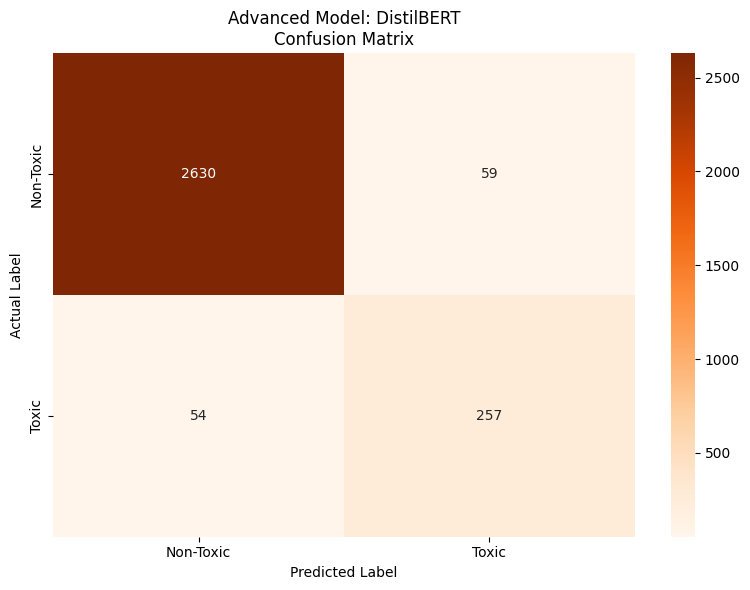

Confusion matrix saved.


In [25]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

print("DistilBERT - Test Set Evaluation")
print("="*55)

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall    = recall_score(all_labels, all_preds)
f1        = f1_score(all_labels, all_preds)

print(f"\nTest Results:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(all_labels, all_preds,
      target_names=['Non-Toxic', 'Toxic']))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Non-Toxic', 'Toxic'],
            yticklabels=['Non-Toxic', 'Toxic'])
plt.title('Advanced Model: DistilBERT\nConfusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('distilbert_confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved.")

## 9. Model Comparison

Compare the performance of both models across all evaluation metrics
to demonstrate the advantage of the DistilBERT advanced model over
the TF-IDF baseline.

Model Comparison - Test Set Results
           TF-IDF + Logistic Regression  DistilBERT
Metric                                             
Accuracy                         0.9411      0.9623
Precision                        0.6613      0.8133
Recall                           0.8603      0.8264
F1 Score                         0.7478      0.8198

Improvement (DistilBERT over Baseline):
  Accuracy: +0.0212
  Precision: +0.1520
  Recall: +-0.0339
  F1 Score: +0.0720


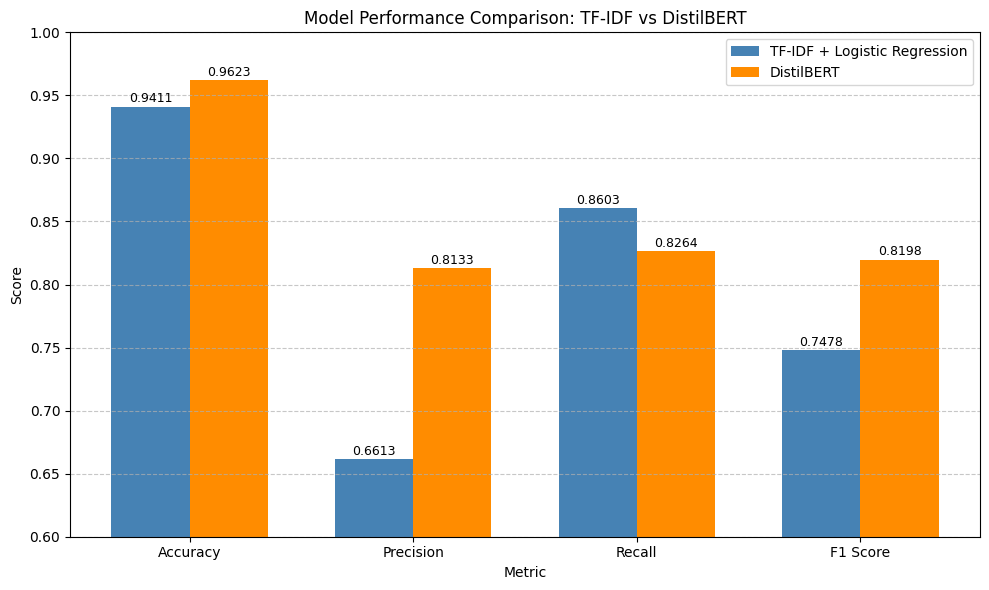

Comparison chart saved.


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Results from both models
results = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'TF-IDF + Logistic Regression': [0.9411, 0.6613, 0.8603, 0.7478],
    'DistilBERT': [0.9623, 0.8133, 0.8264, 0.8198]
}

df_results = pd.DataFrame(results)
df_results = df_results.set_index('Metric')

print("="*55)
print("Model Comparison - Test Set Results")
print("="*55)
print(df_results.to_string())
print("\nImprovement (DistilBERT over Baseline):")
for metric in df_results.index:
    diff = df_results.loc[metric, 'DistilBERT'] - df_results.loc[metric, 'TF-IDF + Logistic Regression']
    print(f"  {metric}: +{diff:.4f}")

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 6))

x     = np.arange(len(df_results.index))
width = 0.35

bars1 = ax.bar(x - width/2, df_results['TF-IDF + Logistic Regression'],
               width, label='TF-IDF + Logistic Regression', color='steelblue')
bars2 = ax.bar(x + width/2, df_results['DistilBERT'],
               width, label='DistilBERT', color='darkorange')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison: TF-IDF vs DistilBERT')
ax.set_xticks(x)
ax.set_xticklabels(df_results.index)
ax.set_ylim(0.6, 1.0)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars1:
    ax.annotate(f'{bar.get_height():.4f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points',
                ha='center', fontsize=9)

for bar in bars2:
    ax.annotate(f'{bar.get_height():.4f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points',
                ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("Comparison chart saved.")

### 9.1 DistilBERT Training Curves

Visualise the training loss and validation F1 score across epochs
to demonstrate model learning progression and confirm that the
model did not overfit during fine-tuning.

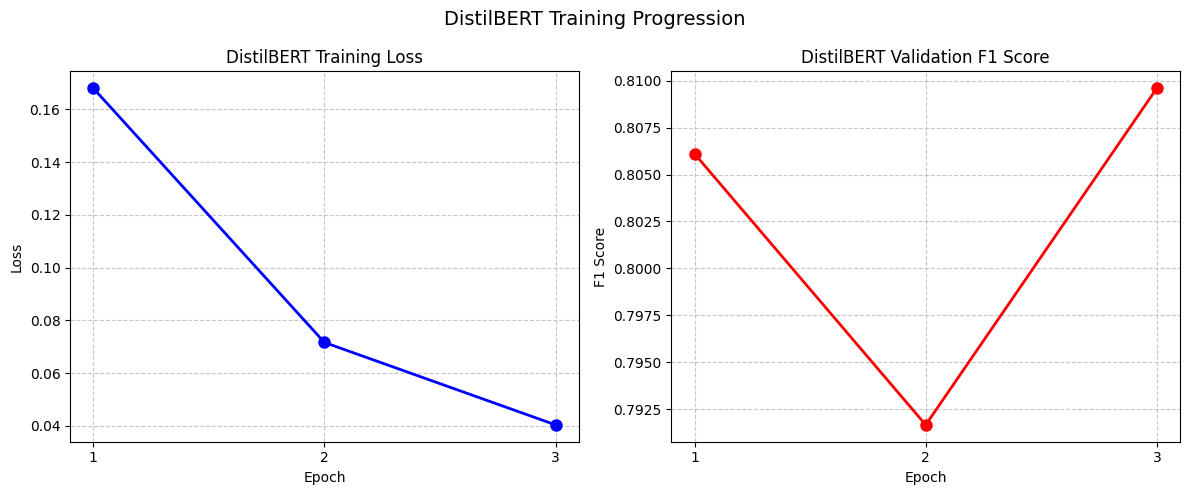

Training curves saved.


In [27]:
import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Training Loss
ax1.plot(epochs, train_losses, 'b-o', linewidth=2, markersize=8)
ax1.set_title('DistilBERT Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_xticks(epochs)
ax1.grid(True, linestyle='--', alpha=0.7)

# Validation F1
ax2.plot(epochs, val_f1_scores, 'r-o', linewidth=2, markersize=8)
ax2.set_title('DistilBERT Validation F1 Score')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1 Score')
ax2.set_xticks(epochs)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.suptitle('DistilBERT Training Progression', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("Training curves saved.")

## 10. Results Summary

A final summary of both model performances on the test set,
highlighting the key findings and improvements achieved by the
advanced DistilBERT model over the TF-IDF baseline.

In [29]:
print("="*55)
print("FINAL RESULTS SUMMARY")
print("="*55)

print("""
Dataset: Jigsaw Toxic Comment Classification
Train samples: 111,519 (full dataset via John's pipeline)
               20,000  (subset used for DistilBERT training)
Val samples:   23,897  (full) / 3,000 (DistilBERT subset)
Test samples:  23,897  (full) / 3,000 (DistilBERT subset)
Class balance: 89.8% Non-Toxic / 10.2% Toxic

MODEL 1 - Baseline: TF-IDF + Logistic Regression
-------------------------------------------------
Accuracy:  0.9411
Precision: 0.6613
Recall:    0.8603
F1 Score:  0.7478

MODEL 2 - Advanced: DistilBERT (fine-tuned)
-------------------------------------------------
Accuracy:  0.9623
Precision: 0.8133
Recall:    0.8264
F1 Score:  0.8198

KEY FINDINGS
-------------------------------------------------
- DistilBERT outperforms TF-IDF baseline on F1 Score by +0.0720
- DistilBERT achieves significantly higher Precision (+0.1520)
  indicating fewer false positives
- TF-IDF achieves slightly higher Recall (+0.0339) due to
  aggressive class balancing
- DistilBERT contextual understanding gives superior overall
  performance for toxic comment detection
""")



FINAL RESULTS SUMMARY

Dataset: Jigsaw Toxic Comment Classification
Train samples: 111,519 (full dataset via John's pipeline)
               20,000  (subset used for DistilBERT training)
Val samples:   23,897  (full) / 3,000 (DistilBERT subset)
Test samples:  23,897  (full) / 3,000 (DistilBERT subset)
Class balance: 89.8% Non-Toxic / 10.2% Toxic

MODEL 1 - Baseline: TF-IDF + Logistic Regression
-------------------------------------------------
Accuracy:  0.9411
Precision: 0.6613
Recall:    0.8603
F1 Score:  0.7478

MODEL 2 - Advanced: DistilBERT (fine-tuned)
-------------------------------------------------
Accuracy:  0.9623
Precision: 0.8133
Recall:    0.8264
F1 Score:  0.8198

KEY FINDINGS
-------------------------------------------------
- DistilBERT outperforms TF-IDF baseline on F1 Score by +0.0720
- DistilBERT achieves significantly higher Precision (+0.1520)
  indicating fewer false positives
- TF-IDF achieves slightly higher Recall (+0.0339) due to 
  aggressive class balancing